# 06 -- Demand-Supply Mismatch Diagnostic (O2)

Implements the classification described in outline 3.4.2 Phase 2, Step 4
("Demand-supply mismatch diagnostic"), which the methodology text describes but which has
never actually been computed -- until now the only O2-adjacent material was the descriptive
EDA panels (03), explicitly flagged there as preliminary, non-causal spatial association.

Standalone: only needs `demand_london.csv` (from 04) and the LSOA boundary shapefile. Does not
depend on 05 -- can run before, during, or after the p-median model.

**Four categories** (the outline names three; a fourth is added here so every LSOA gets an
unambiguous label, with no residual "doesn't fit any category" group):

1. **True desert** -- no existing provision ($e_i=0$), and demand ($B_i$) is at or above the
   London-wide median. A genuine gap.
2. **Low-demand, no provision** -- no existing provision, but demand is below the London-wide
   median. Absence of infrastructure here is not obviously a problem.
3. **Saturated / potentially underprovided** -- provision exists, and mean utilisation
   ($\bar u_i$) is at or above the median among LSOAs that have provision. Existing chargers
   are busier than average; capacity may still be insufficient.
4. **Apparently adequate** -- provision exists and utilisation is below that median.

Thresholds are medians computed from the data itself (not an arbitrary fixed cutoff), so they
don't need to be independently justified or defended as a chosen constant.

## 0. Setup and load data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"
OUTPUT_DIR = os.path.join(BASE, "05_processed")
FIGURES_DIR = os.path.join(BASE, "06_outputs/figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

demand = pd.read_csv(os.path.join(OUTPUT_DIR, "demand_london.csv"))
print("demand_london.csv:", demand.shape, "| columns:", list(demand.columns))
assert len(demand) == 4_994, f"Expected 4,994 London LSOAs, got {len(demand)}"

# Column names differ slightly between the Claude and GPT versions of 04 -- detect both.
UTIL_COL_CANDIDATES = ["u_i", "ubar_i"]
util_col = next((c for c in UTIL_COL_CANDIDATES if c in demand.columns), None)
if util_col is None:
    raise KeyError(f"None of {UTIL_COL_CANDIDATES} found in demand_london.csv -- "
                    f"available columns: {list(demand.columns)}")

BASELINE_DEMAND_COL = "B_i" if "B_i" in demand.columns else "D_A"
DECILE_COL = "london_income_decile" if "london_income_decile" in demand.columns else "income_decile"

print(f"\nUsing utilisation column: '{util_col}'")
print(f"Using baseline demand column: '{BASELINE_DEMAND_COL}'")
print(f"Using deprivation decile column: '{DECILE_COL}'")

required = ["lsoa_code", "e_i", BASELINE_DEMAND_COL, DECILE_COL]
missing = [c for c in required if c not in demand.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

demand_london.csv: (4994, 19) | columns: ['lsoa_code', 'lsoa_name', 'Hi', 'Ci', 'V_i', 'e_i', 'u_i', 'U_i', 'S_eff_i', 'has_evse_i', 'IMD_i', 'income_rank', 'income_decile', 'london_income_decile', 'B_i', 'D_A', 'D_B', 'D_C', 'D_D']

Using utilisation column: 'u_i'
Using baseline demand column: 'B_i'
Using deprivation decile column: 'london_income_decile'


## 1. Classify each LSOA

Two-step split: first by whether provision exists ($e_i$), then by demand (for the no-provision
branch) or utilisation (for the has-provision branch), each against a median computed from the
appropriate reference group.

In [2]:
has_provision = demand["e_i"] > 0

B_median_all = demand[BASELINE_DEMAND_COL].median()
ubar_median_provided = demand.loc[has_provision, util_col].median()

print(f"London-wide median {BASELINE_DEMAND_COL} (all LSOAs): {B_median_all:,.2f}")
print(f"Median {util_col} among LSOAs WITH provision only: {ubar_median_provided:.4f}")


def classify(row):
    if row["e_i"] == 0:
        if row[BASELINE_DEMAND_COL] >= B_median_all:
            return "True desert"
        else:
            return "Low-demand, no provision"
    else:
        if row[util_col] >= ubar_median_provided:
            return "Saturated / potentially underprovided"
        else:
            return "Apparently adequate"


demand["mismatch_category"] = demand.apply(classify, axis=1)

category_order = [
    "True desert",
    "Saturated / potentially underprovided",
    "Apparently adequate",
    "Low-demand, no provision",
]
demand["mismatch_category"] = pd.Categorical(
    demand["mismatch_category"], categories=category_order, ordered=True
)

assert demand["mismatch_category"].isna().sum() == 0, "Every LSOA must receive a category."
assert demand["mismatch_category"].value_counts().sum() == len(demand)

print("\nCategory counts:")
print(demand["mismatch_category"].value_counts().reindex(category_order))
print("\nCategory shares:")
print((demand["mismatch_category"].value_counts(normalize=True)
       .reindex(category_order) * 100).round(1).astype(str) + "%")

London-wide median B_i (all LSOAs): 68.20
Median u_i among LSOAs WITH provision only: 0.0162

Category counts:
mismatch_category
True desert                              1267
Saturated / potentially underprovided    1579
Apparently adequate                      1578
Low-demand, no provision                  570
Name: count, dtype: int64

Category shares:
mismatch_category
True desert                              25.4%
Saturated / potentially underprovided    31.6%
Apparently adequate                      31.6%
Low-demand, no provision                 11.4%
Name: proportion, dtype: str


## 2. Cross-tabulate against income deprivation deciles

This is the step that actually connects O2 to the dissertation's equity narrative -- not just
"where is the mismatch" but "is the mismatch concentrated in more deprived LSOAs".

In [3]:
decile_crosstab = pd.crosstab(
    demand[DECILE_COL], demand["mismatch_category"], normalize="index"
)[category_order] * 100

print("Row-normalised (%), each row sums to 100:")
print(decile_crosstab.round(1))

true_desert_by_decile = decile_crosstab["True desert"]
saturated_by_decile = decile_crosstab["Saturated / potentially underprovided"]
print(f"\n'True desert' share, most deprived decile (1): {true_desert_by_decile.loc[1]:.1f}%")
print(f"'True desert' share, least deprived decile (10): {true_desert_by_decile.loc[10]:.1f}%")
print(f"'Saturated/underprovided' share, most deprived decile (1): {saturated_by_decile.loc[1]:.1f}%")
print(f"'Saturated/underprovided' share, least deprived decile (10): {saturated_by_decile.loc[10]:.1f}%")

Row-normalised (%), each row sums to 100:
mismatch_category     True desert  Saturated / potentially underprovided  \
london_income_decile                                                       
1                             9.6                                   33.2   
2                            18.0                                   30.7   
3                            20.8                                   34.9   
4                            23.8                                   37.4   
5                            27.5                                   31.5   
6                            25.1                                   32.3   
7                            27.2                                   31.8   
8                            29.9                                   30.5   
9                            33.7                                   28.9   
10                           38.2                                   25.2   

mismatch_category     Apparently adequate  Lo

## 3. Figure -- Panel A: classification map, Panel B: decile distribution

Panel A uses the red/amber/grey discrete scheme already established for categorical maps in
this dissertation, extended with a pale green for "apparently adequate" (the one category that
genuinely isn't a concern, so it shouldn't share a colour family with the two problem
categories or with the neutral grey "not really a mismatch" category).

LSOA boundaries matched: 4994 / 4994 expected


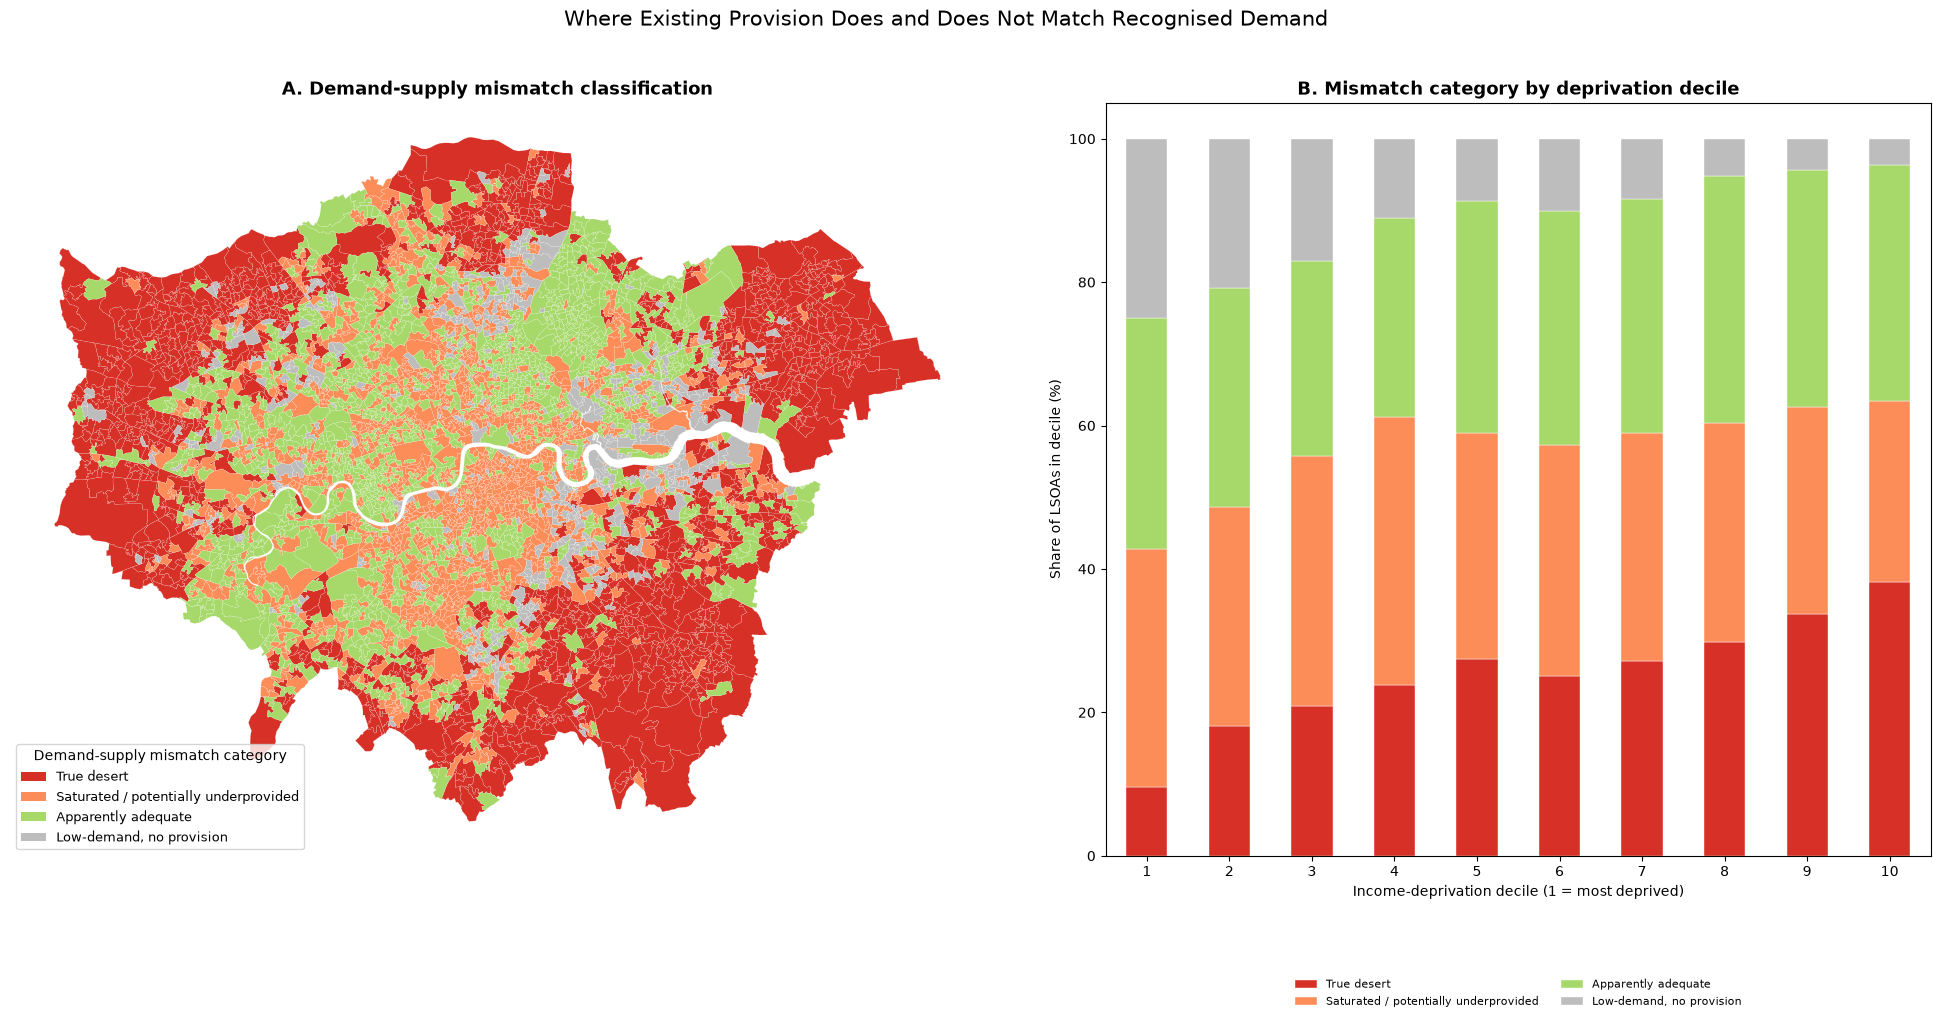

In [4]:
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(demand["lsoa_code"])].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]
print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(demand)} expected")

category_colors = {
    "True desert": "#d73027",                              # red
    "Saturated / potentially underprovided": "#fc8d59",     # amber
    "Apparently adequate": "#a6d96a",                        # pale green
    "Low-demand, no provision": "#bdbdbd",                   # grey -- not a real mismatch
}

map_data = lsoa_london.merge(
    demand[["lsoa_code", "mismatch_category"]], on="lsoa_code", how="left"
)

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(20, 10), gridspec_kw={"width_ratios": [1.3, 1]})

for category in category_order:
    subset = map_data.loc[map_data["mismatch_category"] == category]
    subset.plot(ax=ax_map, color=category_colors[category], edgecolor="white", linewidth=0.1)

legend_handles = [Patch(facecolor=category_colors[c], edgecolor="none", label=c)
                  for c in category_order]
ax_map.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True,
              title="Demand-supply mismatch category")
ax_map.set_title("A. Demand-supply mismatch classification", fontsize=13, fontweight="bold")
ax_map.axis("off")

decile_crosstab.loc[range(1, 11), category_order].plot(
    kind="bar", stacked=True, ax=ax_bar,
    color=[category_colors[c] for c in category_order],
    edgecolor="white", linewidth=0.3,
)
ax_bar.set_xlabel("Income-deprivation decile (1 = most deprived)")
ax_bar.set_ylabel("Share of LSOAs in decile (%)")
ax_bar.set_title("B. Mismatch category by deprivation decile", fontsize=13, fontweight="bold")
ax_bar.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, frameon=False)
ax_bar.set_xticklabels(range(1, 11), rotation=0)

plt.suptitle("Where Existing Provision Does and Does Not Match Recognised Demand",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_mismatch_diagnostic.png"), dpi=300, bbox_inches="tight")
plt.show()

## 4. Save outputs

In [5]:
output_cols = ["lsoa_code", "e_i", util_col, BASELINE_DEMAND_COL, DECILE_COL, "mismatch_category"]
mismatch_output = demand[output_cols].copy()

output_path = os.path.join(OUTPUT_DIR, "mismatch_diagnostic.csv")
mismatch_output.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

decile_crosstab.to_csv(os.path.join(OUTPUT_DIR, "mismatch_by_decile.csv"))
print(f"Saved: {os.path.join(OUTPUT_DIR, 'mismatch_by_decile.csv')}")

mismatch_output.head()

Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/mismatch_diagnostic.csv
Saved: /Users/alexia/Documents/CASA/Dissertation/05_processed/mismatch_by_decile.csv


,lsoa_code,e_i,u_i,B_i,london_income_decile,mismatch_category
0,E01000001,1,0.243911,51.734189,10,Saturated / potentially underprovided
1,E01000002,1,0.015972,37.786227,10,Apparently adequate
2,E01000003,0,NaN,27.642857,9,"Low-demand, no provision"
3,E01000005,0,NaN,14.952273,7,"Low-demand, no provision"
4,E01000006,0,NaN,64.835065,4,"Low-demand, no provision"


## 5. Update pipeline_summary.csv

In [6]:
pipeline_summary_path = os.path.join(OUTPUT_DIR, "pipeline_summary.csv")
pipeline_summary = pd.read_csv(pipeline_summary_path)

new_row = {"output": "mismatch_diagnostic.csv", "rows": len(mismatch_output),
           "observation_unit": "LSOA"}
if (pipeline_summary["output"] == new_row["output"]).any():
    pipeline_summary.loc[pipeline_summary["output"] == new_row["output"],
                          ["rows", "observation_unit"]] = [new_row["rows"], new_row["observation_unit"]]
else:
    pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([new_row])], ignore_index=True)

pipeline_summary.to_csv(pipeline_summary_path, index=False)
print(pipeline_summary.to_string(index=False))

                        output   rows  observation_unit
       census_london_clean.csv   4994              LSOA
          imd_london_clean.csv   4994              LSOA
       evse_registry_clean.csv  38358              EVSE
         osev_london_clean.csv  23008 charging location
              zapmap_clean.csv 524116  charging session
      evse_utilisation_all.csv  38358              EVSE
location_utilisation_clean.csv  23008 charging location
       location_lsoa_clean.csv  23008 charging location
         lsoa_supply_clean.csv   4994              LSOA
     cleaning_decision_log.csv      7 cleaning decision
       mismatch_diagnostic.csv   4994              LSOA
